# 2.1 Differential expression and enrichment

## Workflow outline
1. Load the final clustered AnnData object from `1_5_clustering.ipynb`.
2. Define helper functions for enrichment result filtering and plotting.
3. Run BAM-versus-microglia differential testing and enrichment.
4. Run microglia cluster-level differential testing and enrichment.
5. Visualize selected marker sets with heatmaps, dot plots, and UMAP panels.


## Setup
Imports, plotting defaults, and project paths.


In [1]:
# import packages
import os
os.chdir('/Users/apple/Desktop/SCP_Projects/')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import scdia as sd

# set data and figure dir
data_dir = 'SCP_Microglia/data/'
fig_dir = 'SCP_Microglia/figures/2_1_de_analysis/'
results_dir = 'SCP_Microglia/results/2_1_de_analysis/'

if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

sc.settings.verbosity = 3

In [2]:
def apply_publication_style(font_size=12, axes_linewidth=1.0):
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': font_size,
        'axes.titlesize': font_size + 1,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size,
        'legend.frameon': False,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.transparent': False,
    })
    sns.set_theme(context='paper', style='ticks', rc={
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
        'axes.linewidth': axes_linewidth,
        'legend.frameon': False,
    })

apply_publication_style()

## Load final clustered data
Read the final clustered AnnData object used for DE testing.


In [3]:
adata_final = sc.read_h5ad("SCP_Microglia/results/1_5_clustering/scp_MG_1c_maxlfq_final_version.h5ad")

In [4]:
adata_final

AnnData object with n_obs × n_vars = 3068 × 3979
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter', 'bbknn_leiden_clusters', 'cca_leiden_clusters'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'age_colors', 'bbknn', 'brain_region_colors', 'cca_leiden_clusters', 'column_id_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'prepare_date_colors', 'umap'
    obsm: 'CCA', 'Combat', 'FastMNN', 'Harmony', 'Liger', 'RPCA', 'Scanorama', 'X_pca', 'X_umap', 'bbknn_umap', 'scPROTEIN', 'scPROTEIN_PCA', 'scVI_nb', 'scVI_normal'
    varm: 'PCs'
    layers: 'log2_t

## Helper functions
Define reusable filtering and enrichment plotting helpers.


In [5]:
from matplotlib.pyplot import show

def filter_de_results(results_df, pvalue_cutoff=0.05):
    results_df_filtered = results_df[results_df['Adjusted P-value'] < pvalue_cutoff].sort_values('Adjusted P-value', ascending=True)
    results_df_filtered['Term'] = results_df_filtered['Term'].str.split('\(GO').str[0]
    results_df_filtered['Term'] = results_df_filtered['Term'].str.split(': ').str[1]
    results_df_filtered['-log10(P-value)'] = -np.log10(results_df_filtered['Adjusted P-value'])
    return results_df_filtered

def plot_enrichment_results(results_df, n=10, fig_size=(8, 4), title=None, color='red', save_path=None, show=False):
    plot_df = results_df.sort_values(by='-log10(P-value)', ascending=False).head(n)
    fig, ax = plt.subplots(figsize=fig_size)
    sns.barplot(
        data=plot_df,
        x='-log10(P-value)', 
        y='Term',
        color=color,
        ax=ax
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.title(title, fontsize=13)
    plt.ylabel('')
    plt.xlabel(r'$-\log_{10}(\text{Adjusted P-value})$')

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    if show:
        plt.show()

### DE test for BAM

In [6]:
sd.tl.de_test(
    adata_final,
    groupby='cca_leiden_clusters',
    group1='5',
    group2=None,
    test='mannwhitneyu',
    key_added='de_test_bam',
    layer='log2_total_normalized',
    missing_value=0,
    log_input=True,
)


In [7]:
results_df_bam_detest_up = sd.tl.enrich_de_genes(
    adata_final,
    de_key='de_test_bam',
    gene_sets=["GO_Biological_Process_2023"],
    direction="up",
    log2foldchange_cutoff=1,
    pvalue_cutoff=0.01,
    organism="Mouse",
)


In [8]:
results_df_bam_detest_up_filtered = filter_de_results(results_df_bam_detest_up, pvalue_cutoff=0.05)

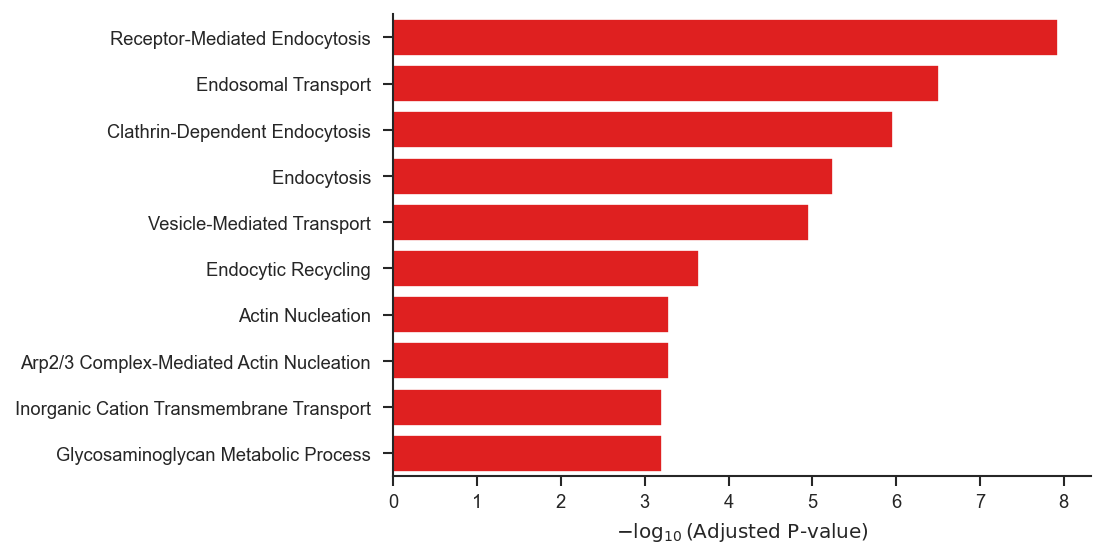

In [9]:
plot_enrichment_results(
    results_df_bam_detest_up_filtered,
    n = 10,
    fig_size=(6, 4), 
    color='red', 
    save_path=fig_dir + 'bam_upregulated_enriched_terms.pdf'
)

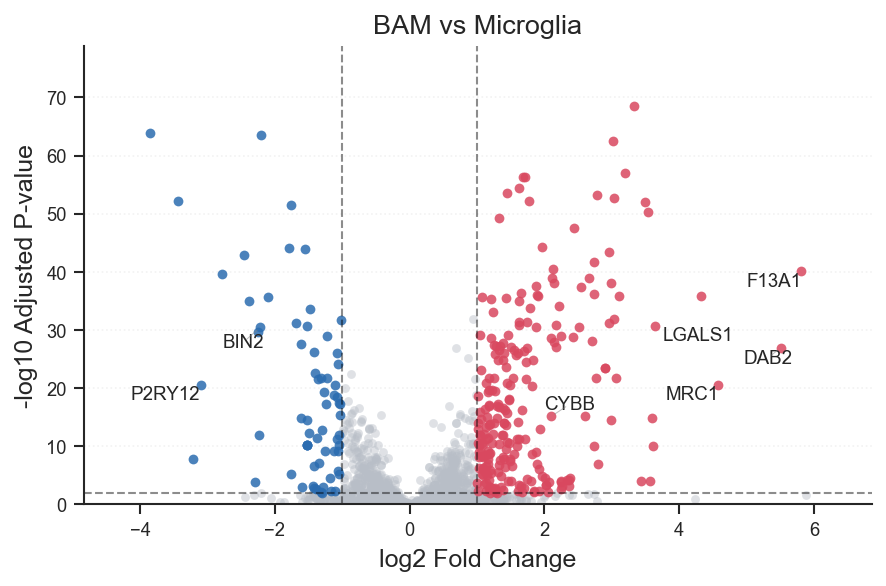

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sd.pl.plot_de_volcano(
    adata_final,
    de_key='de_test_bam',
    adj_pval_cutoff=0.01,
    log2foldchange_cutoff=1,
    title='BAM vs Microglia',
    show_labels=True,
    legend=False,
    n_top=None,
    genes_of_interest=['Mrc1', 'F13a1', 'P2ry12', 'Cybb', 'Lgals1', 'Dab2', 'Bin2'],
    ax=ax,
)
fig.savefig(os.path.join(fig_dir, "de_volcano_bam_vs_microglia.pdf"), dpi=300, bbox_inches='tight')


### Exclude BAM for other DE test

In [11]:
microglia_clusters = ['1', '2', '3', '4']

for cluster in microglia_clusters:
    sd.tl.de_test(
        adata_final,
        groupby='cca_leiden_clusters',
        group1=cluster,
        group2=[c for c in microglia_clusters if c != cluster],
        test='mannwhitneyu',
        key_added=f'de_test_c{cluster}',
        layer='log2_total_normalized',
        missing_value=0,
        log_input=True,
    )


In [12]:
results_df_c1_detest_up = sd.tl.enrich_de_genes(
    adata_final,
    de_key='de_test_c1',
    gene_sets=["GO_Biological_Process_2023"],
    direction="up",
    log2foldchange_cutoff=1,
    pvalue_cutoff=0.01,
    organism="Mouse",
)


In [13]:
results_df_c1_detest_up_filtered = filter_de_results(results_df_c1_detest_up, pvalue_cutoff=0.05)

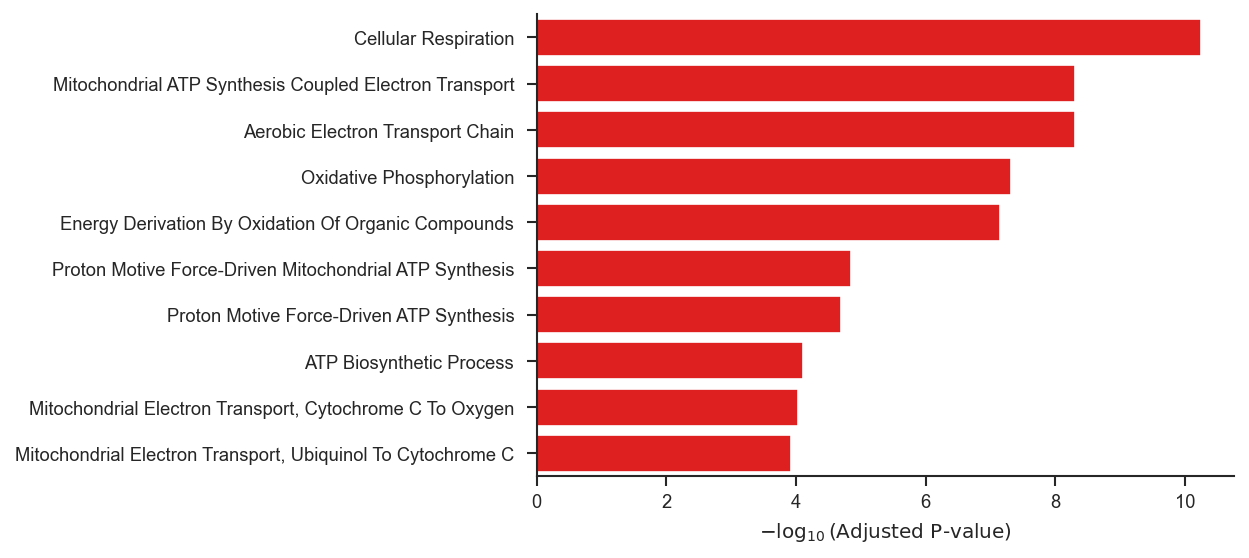

In [14]:
plot_enrichment_results(
    results_df_c1_detest_up_filtered,
    n = 10,
    fig_size=(6, 4), 
    color='red', 
    save_path=fig_dir + 'c1_upregulated_enriched_terms.pdf'
)

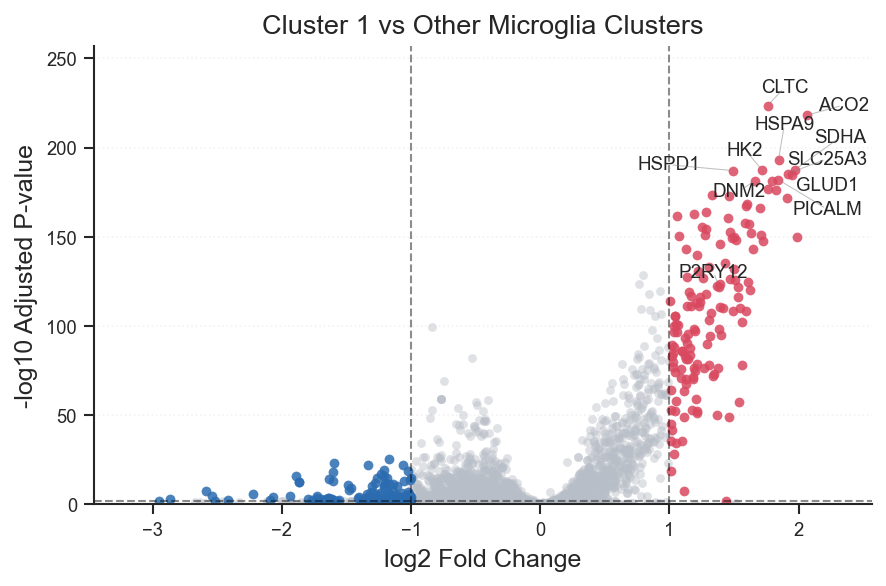

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
sd.pl.plot_de_volcano(
    adata_final,
    de_key='de_test_c1',
    adj_pval_cutoff=0.01,
    log2foldchange_cutoff=1,
    title='Cluster 1 vs Other Microglia Clusters',
    show_labels=True,
    legend=False,
    n_top=10,
    rank_by='pval_adj',
    genes_of_interest=['P2ry12'],
    ax=ax,
)
fig.savefig(os.path.join(fig_dir, "de_volcano_cluster1_vs_others.pdf"), dpi=300, bbox_inches='tight')


In [16]:
results_df_c3_detest_up = sd.tl.enrich_de_genes(
    adata_final,
    de_key='de_test_c3',
    gene_sets=["GO_Biological_Process_2023"],
    direction="up",
    log2foldchange_cutoff=0.5,
    pvalue_cutoff=0.05,
    organism="Mouse",
)


In [17]:
results_df_c3_detest_up_filtered = filter_de_results(results_df_c3_detest_up, pvalue_cutoff=0.05)

### Plot heatmap

In [19]:
marker_list = [
    "Arg1", "Lamp1", "Wdr77", "Anxa2", "Anxa7", "Anxa11",
    "Lgalsl", "Lgals3", "Gba1", "Aloxe3", 
    "Tgm1", "Tgm3", "Prdx2", "Flna", "Flnb", "Got1"
]

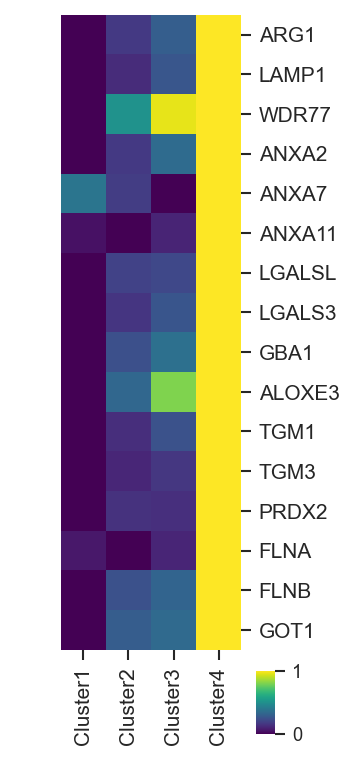

In [25]:
adata_microglia = adata_final[adata_final.obs['cca_leiden_clusters'].isin(['1', '2', '3', '4'])]
df = pd.DataFrame(adata_microglia.layers['log2_total_normalized_fc_nan'], index=adata_microglia.obs['cca_leiden_clusters'], columns=adata_microglia.var_names).groupby(level=0).mean()[marker_list]
df = df - df.min()
df = df / df.max()
df = df.T

cl_map = sns.clustermap(
    df,
    col_cluster=False,
    row_cluster=False,
    annot_kws={'fontsize': 6.5},
    cmap = "viridis",
    figsize=(2.5, 6),
    cbar_pos=(0.7, 0, 0.05, 0.07)
)

cl_map.ax_heatmap.set_xlabel('')
cl_map.ax_heatmap.set_ylabel('')
# use upper yticks
cl_map.ax_heatmap.set_yticklabels([label.get_text().upper() for label in cl_map.ax_heatmap.get_yticklabels()], rotation=0, fontsize=10)

cl_map.ax_col_dendrogram.set_visible(False)

cl_map.ax_heatmap.set_xticklabels(['Cluster1', 'Cluster2', 'Cluster3', 'Cluster4'], rotation=90, fontsize=10)

plt.savefig(fig_dir + "marker_genes_heatmap.pdf", dpi=300, bbox_inches='tight')

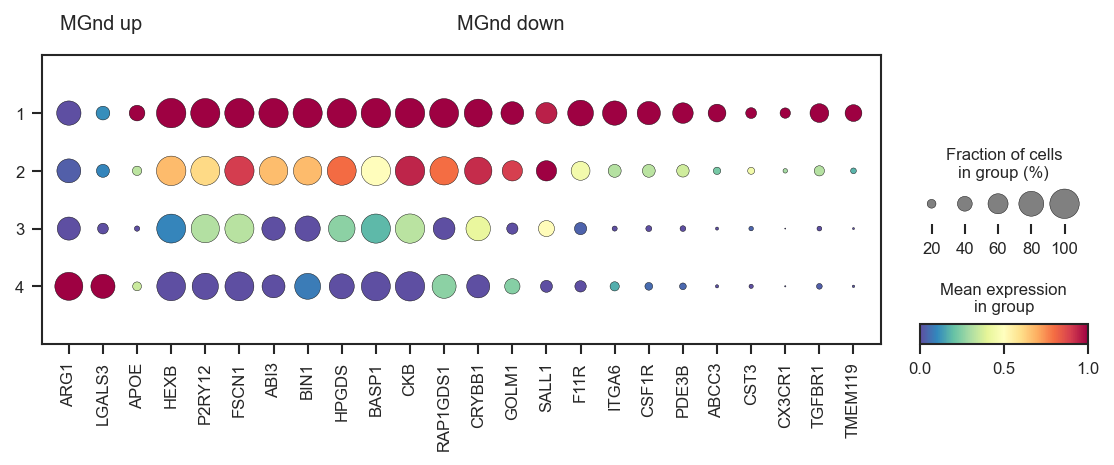

In [30]:
mgnd_markers_dict = {
    "MGnd up": ["Arg1", "Lgals3", "Apoe"], 
    "MGnd down": ["Hexb", "P2ry12", "Fscn1", "Abi3", "Bin1", "Hpgds", "Basp1", "Ckb", "Rap1gds1", "Crybb1", "Golm1", "Sall1", "F11r", "Itga6", "Csf1r", "Pde3b", "Abcc3", "Cst3", "Cx3cr1", "Tgfbr1", "Tmem119"]
}

dp = sc.pl.dotplot(
    adata_final[adata_final.obs['cca_leiden_clusters'].isin(['1', '2', '3', '4'])],
    var_names=mgnd_markers_dict,
    groupby='cca_leiden_clusters',
    layer='log2_total_normalized',
    standard_scale='var',
    cmap="Spectral_r",
    show=False,
    return_fig=True,
    figsize=(9, 2.5),
    var_group_rotation=0
)

main_ax = dp.get_axes()['mainplot_ax']
main_ax.set_xticklabels([label.get_text().upper() for label in main_ax.get_xticklabels()])

plt.savefig(fig_dir + "mgnd_markers_dotplot.pdf", bbox_inches='tight')

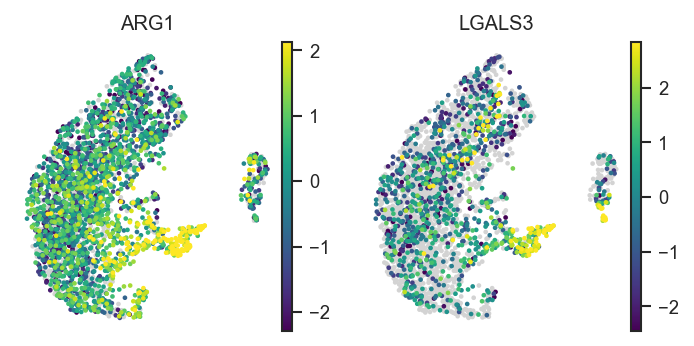

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5))
for i, gene in enumerate(['Arg1', 'Lgals3']):
    sc.pl.umap(
        adata_final,
        color=gene,
        size=20,
        cmap='viridis',
        layer='log2_total_normalized_fc_nan',
        vmin='p5',
        vmax='p95',
        ax=axes[i],
        frameon=False,
        title=gene.upper(),
        show=False
    )
plt.savefig(fig_dir + "C4_marker_umap.pdf", dpi=300, bbox_inches='tight')